## Fractalizing the Initial Value of the given example1, in the Paper of Sine Gordan Equation

In [14]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from SG_solver import rbf_matrix, second_divided_difference
from fractal_SG_solver_new import d2_fractal_L_W2 
from fractal_SG_solver_new import ddphi, H5_dd, pointwise_fractal
from alpha_fractal_function import alpha_fractalize,alpha_fractalize_second_derivative

$$\frac{\partial^2 u}{\partial t^2} = \frac{\partial^2 u}{\partial x^2} \quad ; -1 \le x \le 1$$

Initial Conditions
$$u(x, 0) = f(x) = \sin^{\beta}(\pi x),$$

$$u_t(x, 0) = g(x) = 0$$

with the boundary conditions

$$u(-1,t) = u(1,t) = 0.$$

The analytical solution is given in $[17]$ as

$$u(x,t) = \frac{1}{2}(\sin^{\beta}(\pi(x+t)) + \sin^{\beta}(\pi(x-t))).$$

In [15]:
# Paper Example 1 parameters.
a = -1.0
b = 1.0
#######################
K = 8
s = 0.8
c = 0.027 
################
h = 0.01
tau = 0.005
################
T = 1

In [16]:
n = (b - a) / h

if n != int(n):
    raise ValueError("h must divide b-a exactly.")

n = int(n)

if n % K != 0:
    raise ValueError("n must be divisible by K because the paper defines N = n / K.")

N = n // K
Nt = int(round(T / tau))

x = np.linspace(a, b, n + 1)

# Interpolation center indices k_j, j = 1,...,N
k_idx = np.concatenate(([1], K * np.arange(1, N - 1), [n - 1])).astype(int)

xk = x[k_idx]
xkj = []
for j in range(1, N+1):
    if j == 1:
        value = float(x[1])
        xkj.append(value)

    elif 1 < j < N:
        value = a + ((j - 1) * (b - a)) / N
        xkj.append(value)
    elif j == N:
        value = float(x[n - 1])
        xkj.append(value)

## Fractalizing Initial condition
Fractalized Initial Conditions
$$u(x, 0) = f^{\beta}(x) = \sin^{\beta}(\pi x)$$

$$u_t(x, 0) = g(x) = 0$$

Main Function:                              
$$f(x) = \sin(\pi x)$$

Base Function:
$$g(x) = \frac{x^2 - x^4}{e^x + 2}$$

In [17]:
def f(x):
    y = np.sin(np.pi * x)
    return np.where(np.isclose(y, 0.0, atol=1e-12), 0.0, y)

def g(x):
    return (x**2 - x**4)/(np.exp(x) + 2)

In [18]:
f_beta = [-0.02, 0.015, -0.01, -0.01, 0.015, -0.02] 
n_subintervals = len(f_beta)
n_iter = 4
X = np.linspace(a, b, n_subintervals + 1)
sine_pi_fractal = alpha_fractalize(f, g, -1, 1, n_subintervals, f_beta, n_iter)

f(-1) = 0.0, f(1) = 0.0
g(-1) = 0.0, g(1) = 0.0


## Fractalizing Analytical Solution

In [19]:
def wrap_to_period(x, tol=1e-12):
    y = ((x + 1.0) % 2.0) - 1.0

    # snap values extremely close to endpoints / zero
    if np.isscalar(y):
        if abs(y + 1.0) < tol:
            return -1.0
        if abs(y) < tol:
            return 0.0
        if abs(y - 1.0) < tol:
            return 1.0
        return y
    else:
        y = np.where(np.abs(y + 1.0) < tol, -1.0, y)
        y = np.where(np.abs(y) < tol, 0.0, y)
        y = np.where(np.abs(y - 1.0) < tol, 1.0, y)
        return y
    

def f_exact_u(x, t):
    x_plus = wrap_to_period(x + t)
    x_minus = wrap_to_period(x - t)

    part_1 = pointwise_fractal(x_plus, sine_pi_fractal)
    part_2 = pointwise_fractal(x_minus, sine_pi_fractal)

    return 0.5 * (part_1 + part_2)

In [20]:
# Compute the exact solution at time T
f_u_exact = np.asarray([f_exact_u(x[d], T) for d in range(len(x))])

## Building fractalized numerical solution

In [21]:
f_alpha = [-0.0002, 0, -0.0001, -0.0001, 0, -0.0002]
# f_alpha = 0
n_subintervals = len(f_alpha) #len(f_alpha)
n_iter = 2
X = np.linspace(a, b, n_subintervals + 1)
fractal_dd = alpha_fractalize_second_derivative(ddphi, H5_dd, -2, 2, n_subintervals, f_alpha, n_iter)

In [22]:
# Initial condition at t=0
f_U = np.zeros((Nt + 2, len(x)))
f_U[0, :] = np.asanyarray([pointwise_fractal(x[d], sine_pi_fractal) for d in range(len(x))])  # initial condition at t=0

f_U[0, 0]  = 0.0
f_U[0, -1] = 0.0


# Build approximation of u_xx at t=0
A0 = rbf_matrix(xk, s)
rhs0 = []
for kj in k_idx:
    rhs0.append(second_divided_difference(x, f_U[0, :], kj))
rhs0 = np.asarray(rhs0)

alpha0 = np.linalg.solve(A0, rhs0)


f_uxx0 = np.zeros(len(x))
for i in range(len(x)):
    f_uxx0[i] = d2_fractal_L_W2(i, x, f_U[0, :], xk, alpha0, s, fractal_dd)

# Since g(x)=0
f_U[1, :] = f_U[0, :] + 0.5 * tau**2 * f_uxx0
f_U[1, 0]  = 0.0
f_U[1, -1] = 0.0

In [23]:
# Time stepping:
# u_k^{n+1} = 2u_k^n - u_k^{n-1} + tau^2 * (L_w2 u_k^d)''
# using d instead of n for time level index to avoid confusion with spatial index k.
for d in tqdm(range(1, Nt + 1), desc="Time stepping", unit="step"):
    A = rbf_matrix(xk, s)
    rhs_d = np.asarray([second_divided_difference(x, f_U[d], kj) for kj in k_idx])
    alpha2 = np.linalg.solve(A, rhs_d)

    f_uxx = np.zeros(len(x))
    for i in range( len(x)):
        f_uxx[i] = d2_fractal_L_W2(i, x, f_U[d], xk, alpha2, s, fractal_dd)

    f_U[d + 1, :] = 2.0 * f_U[d, :] - f_U[d - 1, :] + tau**2 * f_uxx

    # Dirichlet boundary conditions
    f_U[d + 1, 0] = 0.0
    f_U[d + 1, -1] = 0.0

Time stepping: 100%|██████████| 200/200 [05:46<00:00,  1.73s/step]


In [24]:
# Final solution and error at time T
f_u_num = f_U[Nt + 1, :]

f_err = (f_u_num -f_u_exact)

f_abs_err = np.abs(f_err)

f_Linf = np.max(f_abs_err)

f_RMS = np.sqrt(np.mean(f_abs_err**2))

print("f_Linf error =", f_Linf)
print("f_RMS error  =", f_RMS)

f_Linf error = 3.7091563898077937
f_RMS error  = 0.8951501513298302


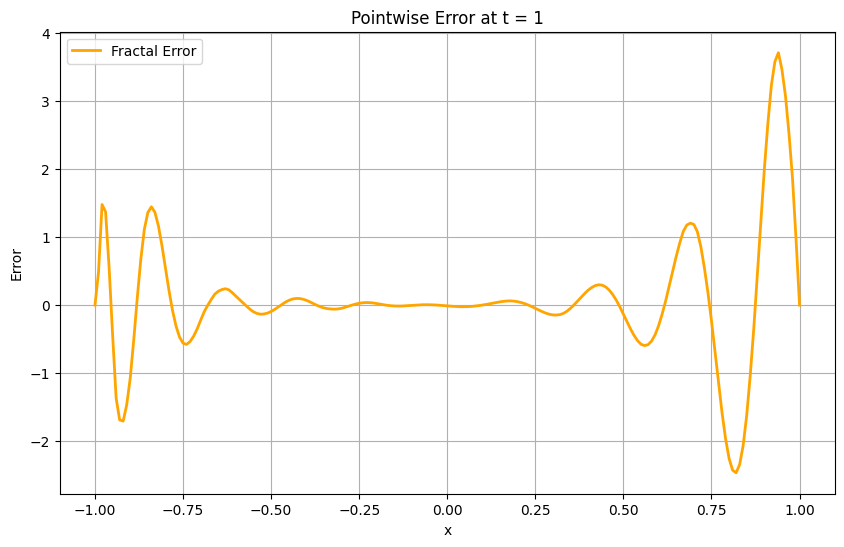

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(x, f_err, label="Fractal Error", color="orange", linewidth=2)
plt.xlabel("x")
plt.ylabel("Error")
plt.title(f"Pointwise Error at t = {T}")
plt.grid(True)
plt.legend()
plt.show()

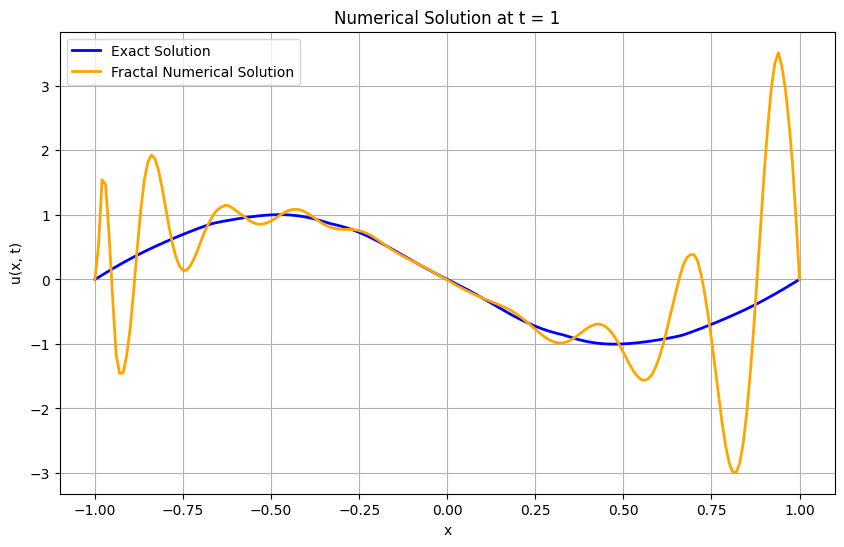

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(x, f_u_exact, label="Exact Solution", color="blue", linewidth=2)
plt.plot(x, f_u_num, label="Fractal Numerical Solution", color="orange", linewidth=2)
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.title(f"Numerical Solution at t = {T}")
plt.grid(True)
plt.legend()
plt.show()